# Occupational Mental Fatigue Prediction Model

## XGBoost

***Library Imports***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import time

***Dataset Initialization***

In [2]:
# Loading the dataset
mefar_data = pd.read_csv('../Datasets/MEFAR_UP.csv')
mefar_data.head()  #Displays the first 5 rows of the dataset              

,BVP,EDA,TEMP,X,Y,Z,HR,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,Attention,Meditation,class
0,-0.116916,0.026215,0.778824,-0.333333,-0.003922,0.388235,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
1,-0.107262,0.026215,0.778824,-0.349020,-0.035294,0.333333,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
2,-0.098919,0.026215,0.778824,-0.349020,-0.035294,0.333333,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
3,-0.092524,0.026215,0.778824,-0.380392,-0.027451,0.356863,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
4,-0.088300,0.026215,0.778824,-0.380392,-0.027451,0.356863,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0


***Correlation Matrix***

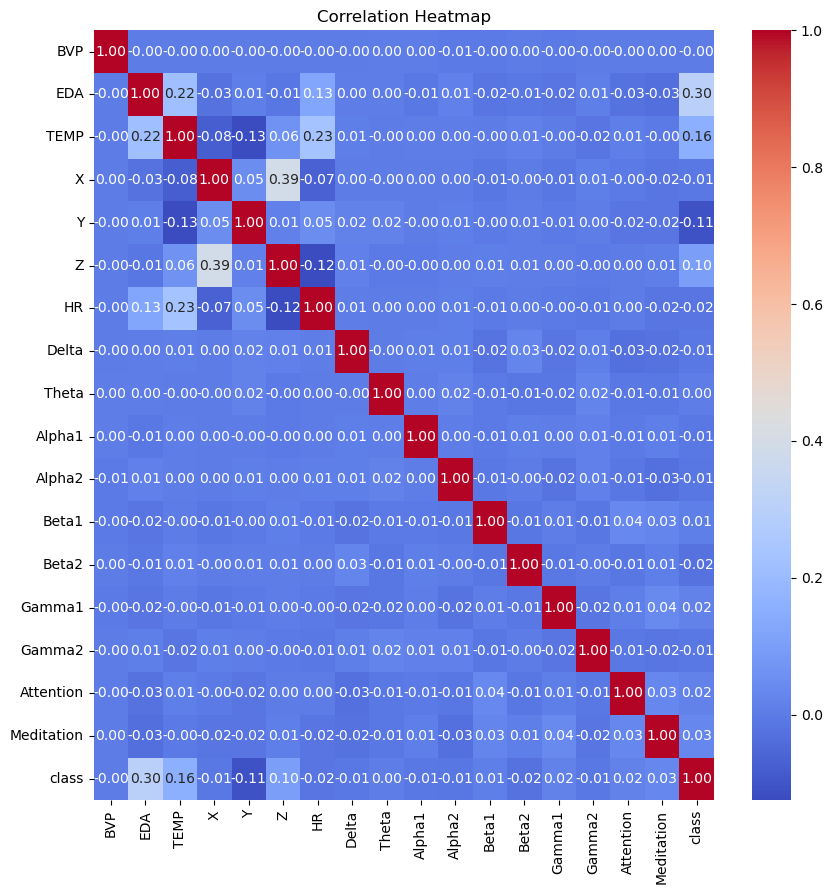

In [3]:
plt.figure(figsize=(10, 10))
sns.heatmap(mefar_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')    
plt.show()

***Feature Distribution***

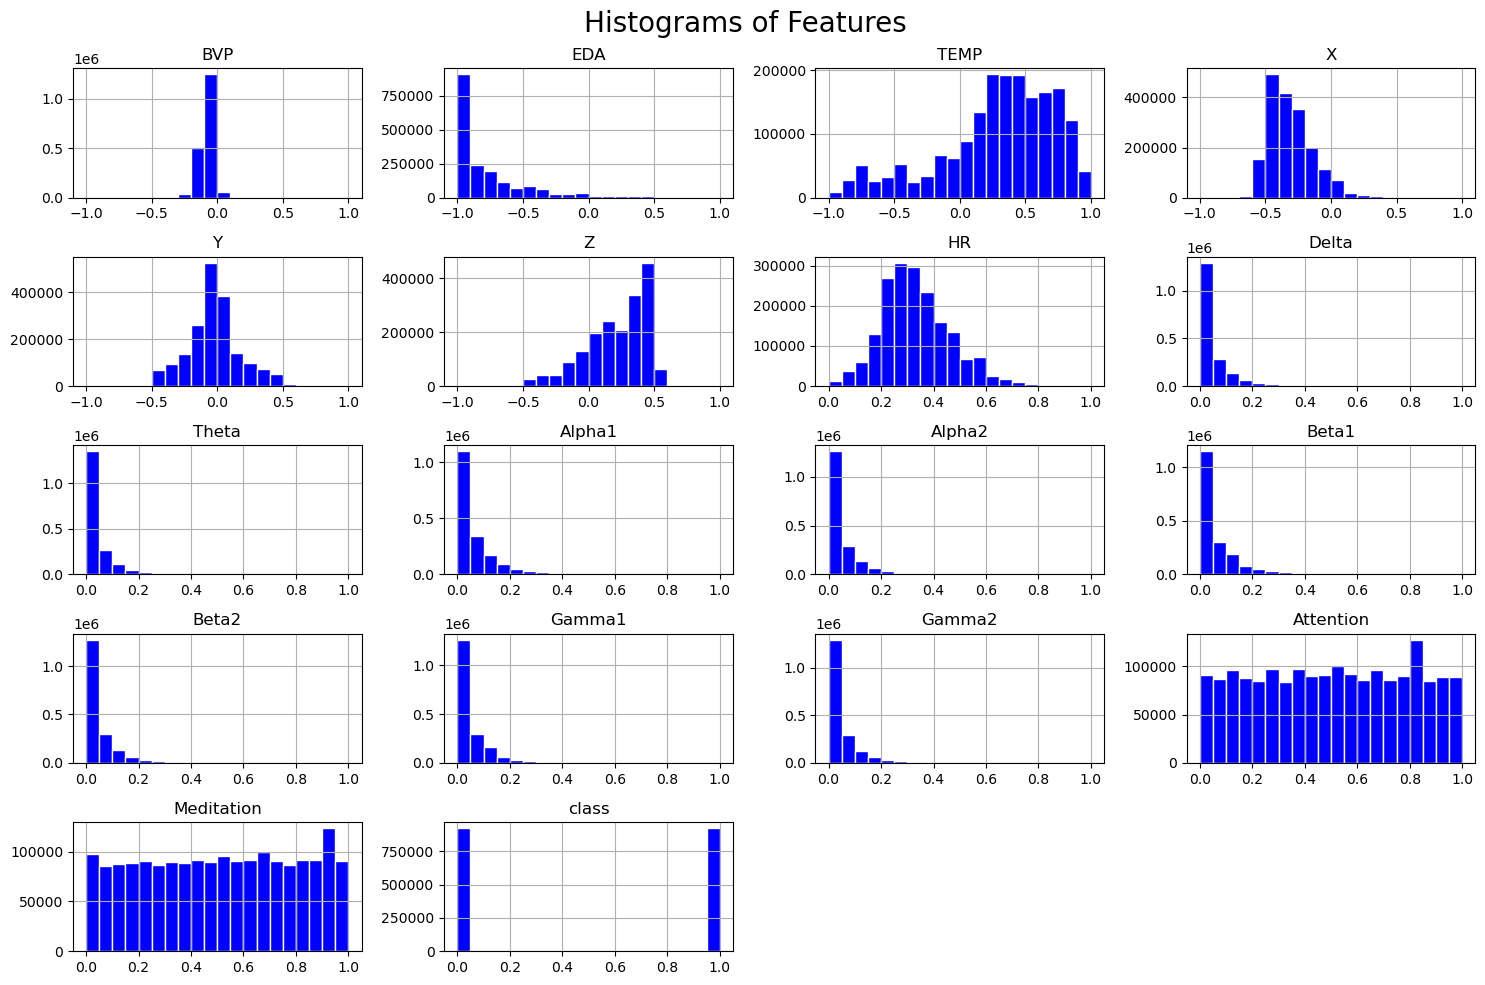

In [4]:
mefar_data.hist(figsize=(15, 10), bins=20, color='blue', edgecolor='white')
plt.suptitle('Histograms of Features', fontsize=20) 
plt.tight_layout()
plt.show()

***Data Preprocessing***

In [5]:
#Storing Input Features
X = mefar_data.drop('class', axis=1)  #Removes the Fatigue Class target variable 

#Storing Target Variables
y = mefar_data['class']                   #Creates a new DataFrame with the Fatigue Class target variable

***Feature Scaling***

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #Standardizing the input features

### Removing Low Impact Features

In [8]:
low_impact_features = [
    'Attention', 'Alpha1', 'Gamma2', 'Theta', 'Beta2',
    'Delta', 'Meditation', 'Beta1', 'Gamma1', 'Alpha2']

X_reduced = X.drop(columns=low_impact_features)

### Updating the model

In [9]:
from sklearn.preprocessing import FunctionTransformer
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y)

### Model Building and Training

In [10]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [5, 7, 10],
    'xgb__learning_rate': [0.1, 0.3],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
tuning_time = time.time() - start

print(f"\nGrid search completed in {tuning_time:.2f}s")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")

# Test set evaluation
y_pred_tuned = grid_search.predict(X_test)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"Test F1 Score: {f1_tuned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
                          target_names=['No Fatigue', 'Fatigue']))

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Grid search completed in 803.55s

Best Parameters:
  xgb__colsample_bytree: 1.0
  xgb__learning_rate: 0.3
  xgb__max_depth: 10
  xgb__n_estimators: 200
  xgb__subsample: 0.8

Best CV F1 Score: 1.0000
Test F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Fatigue       1.00      1.00      1.00    184659
     Fatigue       1.00      1.00      1.00    184659

    accuracy                           1.00    369318
   macro avg       1.00      1.00      1.00    369318
weighted avg       1.00      1.00      1.00    369318



### Cross-validation

In [11]:
best_xgb = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_xgb, X_reduced, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

print(f"CV F1 Scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV F1 Scores: [0.99999188 0.99998917 1.         0.99999458 0.99999188]
Mean: 1.0000 (+/- 0.0000)


Confusion Matrix:
[[184659      0]
 [     3 184656]]


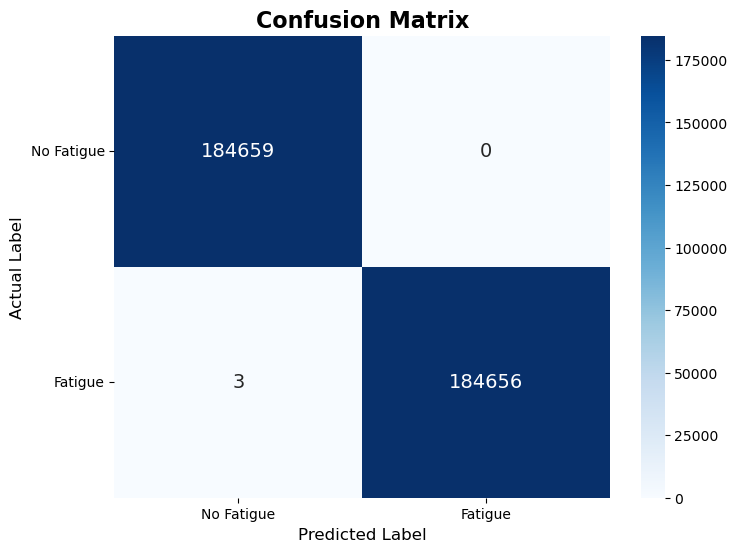

In [15]:
cm = confusion_matrix(y_test, y_pred_tuned)

class_labels = ['No Fatigue', 'Fatigue']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

plt.savefig('XG_confusion_matrix_UP.png')

print("Confusion Matrix:")
print(cm)

### Save Tuned Model

In [14]:
import joblib
joblib.dump(grid_search.best_estimator_, 'Occupational Mental Fatigue Model_XG_UP.pkl')

['Occupational Mental Fatigue Model_XG_UP.pkl']